# Analyse Train results

L'objectif de ce notebook est d'analyser les résultats d'entraînements obtenus avec le script 2-autoencoder-convolution.
Ces résultats sont sauvegardés dans le fichier 0_train_results.csv.

In [78]:
import pandas as pd
import numpy as np

df = pd.read_csv("output/2-autoencoder-convolution/0_train_results.csv", sep=",")
df.head()

,date,category,resized_dimension,batch_size,grayscale,color_augmentation,move_augmentation,model_type,retrain_layers,loss,error_score,roc_auc,tpr,fpr
0,2026-07-10 19:20:20,bottle,"(128, 128)",16,False,True,True,convtl,0,mae,mse,0.939748,0.942446,0.500000
1,2026-07-10 19:21:57,transistor,"(128, 128)",16,False,True,True,convtl,0,mae,mse,0.766667,0.625000,0.200000
2,2026-07-10 19:26:08,cable,"(128, 128)",16,False,True,True,convtl,0,mae,mse,0.813156,0.619565,0.224138
3,2026-07-10 19:27:27,capsule,"(128, 128)",16,False,True,True,convtl,0,mae,mse,0.602314,0.293578,0.260870
4,2026-07-10 19:28:41,carpet,"(128, 128)",16,False,True,True,convtl,0,mae,mse,0.362360,0.258427,0.392857


In [79]:
# Clean data

textures = ['carpet', 'grid', 'leather', 'tile', 'wood', 'metal_plate']

df["batch_size"] = df["batch_size"].astype(int)
df["resized_dimension"] = df["resized_dimension"].str.extract(r'(\d+)').astype(int)

df = df.replace({True:1, False:0})

# Sort values
df = df.sort_values(["category", "roc_auc"], ascending=[True, False])

bests_by_cat = df.loc[df.groupby(["category"])["roc_auc"].idxmax()]

df["texture"] = df["category"].isin(textures).astype(int)

df.loc[(~ df["model_type"].isin(['convtl', 'convtl_dense'])) & (df['retrain_layers']!=0), "retrain_layers"] = 0

df.head()

,date,category,resized_dimension,batch_size,grayscale,color_augmentation,move_augmentation,model_type,retrain_layers,loss,error_score,roc_auc,tpr,fpr,texture
200,2026-07-22 14:53:21,bottle,256,8,1,0,0,convtl,4,mae,mse,0.978417,1.000000,0.70,0
106,2026-07-12 17:51:03,bottle,128,8,0,0,0,convtl_dense,4,mse,mae,0.974101,0.992806,0.60,0
57,2026-07-11 18:29:26,bottle,128,16,0,0,0,convtl,0,mse,mae,0.964928,0.971223,0.45,0
128,2026-07-12 19:33:52,bottle,128,8,0,1,1,convtl,-1,mse,mae,0.959353,0.985612,0.60,0
245,2026-07-23 14:21:28,bottle,224,8,0,0,0,convtl_dense,4,mae,mse,0.958273,0.971223,0.40,0


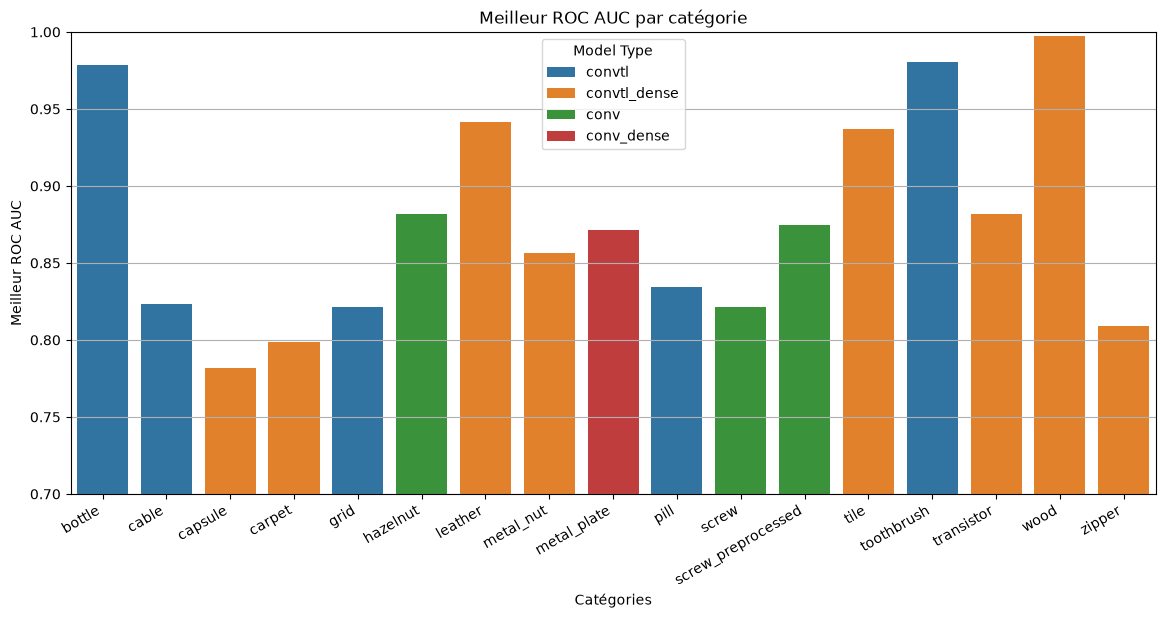

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.barplot(data=bests_by_cat, x="category", y="roc_auc", hue="model_type")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.7,1.0)
plt.grid(axis='y')
plt.ylabel("Meilleur ROC AUC")
plt.xlabel("Catégories")
plt.title("Meilleur ROC AUC par catégorie")

plt.legend(title="Model Type")

#plt.savefig('best_rocauc_by_cat.png', bbox_inches="tight", dpi=300)
plt.show();

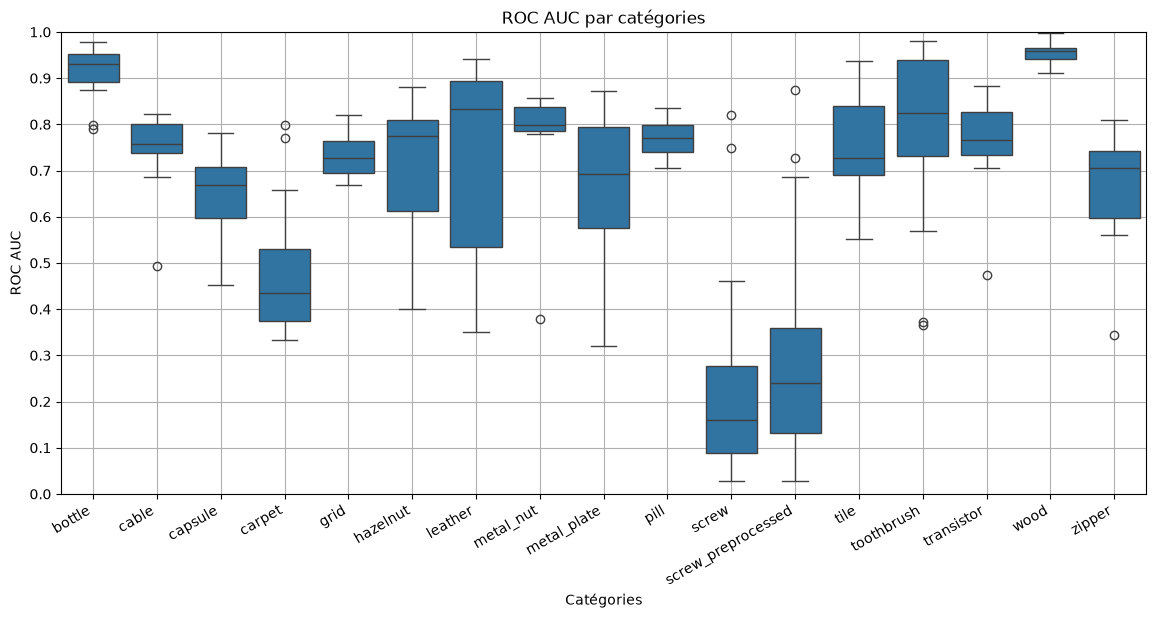

In [81]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="category", y="roc_auc")
plt.xticks(rotation=30, ha="right")

plt.yticks(np.arange(0,1.01,0.1), [f"{y:0.1f}" for y in np.arange(0,1.01,0.1)])
plt.grid(True)
plt.ylabel("ROC AUC")
plt.xlabel("Catégories")
plt.title("ROC AUC par catégories")
plt.ylim(0,1.0)

plt.show();

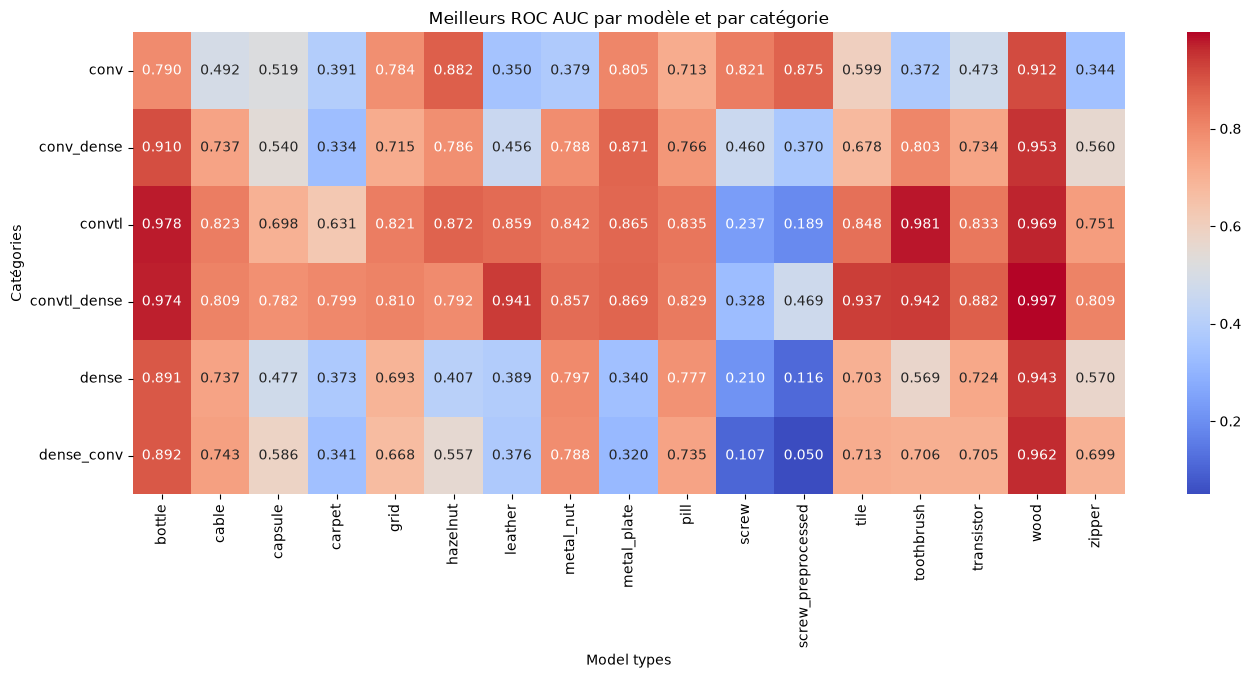

In [ ]:
# Heatmap ROC AUC par model_type / categorie

bests_by_model_cat = df.loc[df.groupby(["model_type", "category"])["roc_auc"].idxmax()]
ct_model_cat = pd.crosstab(bests_by_model_cat["model_type"], bests_by_model_cat["category"], bests_by_model_cat["roc_auc"], 
            rownames=["Catégories"], colnames=["Model types"], aggfunc="max")

plt.figure(figsize=(16,6))
sns.heatmap(ct_model_cat, cmap="coolwarm", annot=True, fmt=".3f")
plt.yticks(rotation=0)
plt.title("Meilleurs ROC AUC par modèle et par catégorie")

plt.show();


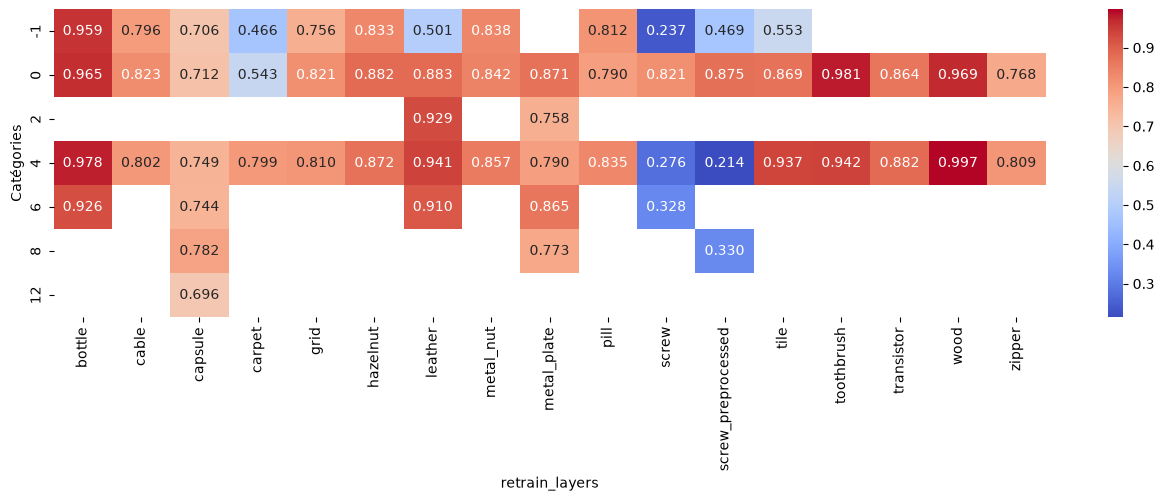

In [83]:
# Heatmap ROC AUC par color mode / categorie

param_to_analyze = "retrain_layers"

bests_by_param_cat = df.loc[df.groupby([param_to_analyze, "category"])["roc_auc"].idxmax()]
ct_param_cat = pd.crosstab(bests_by_param_cat[param_to_analyze], bests_by_param_cat["category"], bests_by_param_cat["roc_auc"], 
            rownames=["Catégories"], colnames=[param_to_analyze], aggfunc="max")

plt.figure(figsize=(16,4))
sns.heatmap(ct_param_cat, cmap="coolwarm", annot=True, fmt=".3f")
plt.show();

,resized_dimension,batch_size,retrain_layers,roc_auc,conv,conv_dense,convtl,convtl_dense,dense,dense_conv,mae,mse
238,224,8,4,0.798957,0,0,0,1,0,0,1,0
239,224,8,4,0.770867,0,0,0,1,0,0,0,1
220,256,8,4,0.657303,0,0,0,1,0,0,1,0
109,128,8,4,0.650883,0,0,0,1,0,0,0,1
242,224,8,4,0.630819,0,0,1,0,0,0,1,0
241,224,8,0,0.542937,0,0,0,1,0,0,1,0
78,128,8,0,0.494783,0,0,0,1,0,0,0,1
203,256,8,4,0.490770,0,0,1,0,0,0,1,0
125,128,8,-1,0.466292,0,0,0,1,0,0,0,1
93,128,8,0,0.455457,0,0,0,1,0,0,1,0


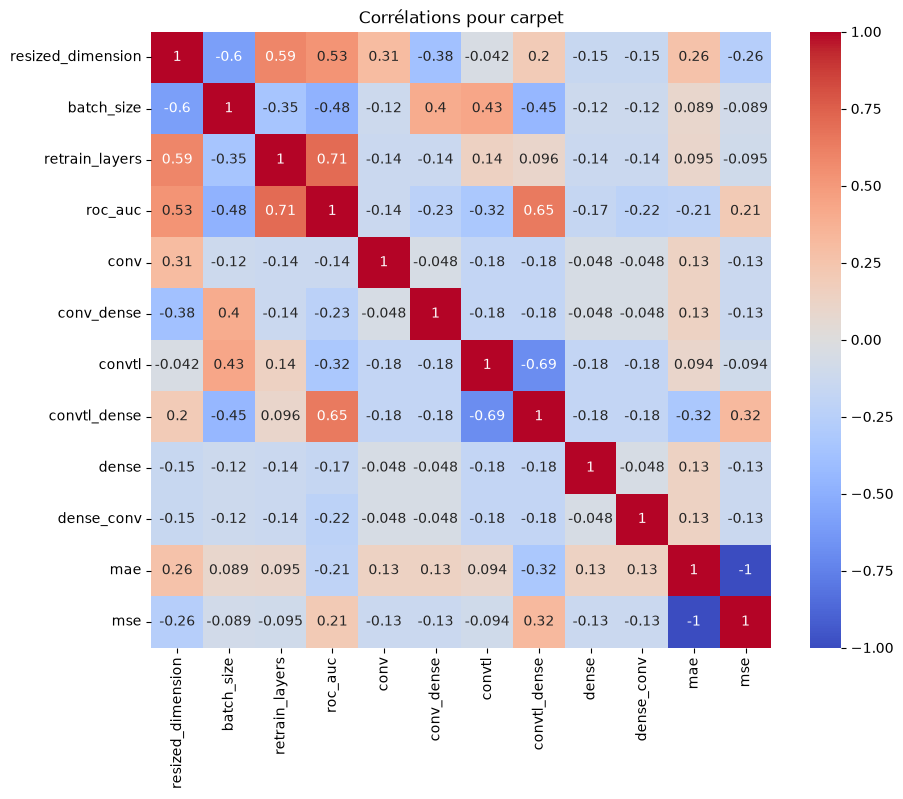

In [84]:
import seaborn as sns

category = 'carpet'

df_corr = pd.concat([
    df["category"], 
    df.drop(['tpr','fpr','texture'],axis=1).select_dtypes(['float', 'int']), 
    pd.get_dummies(df['model_type'], dtype=int), 
    pd.get_dummies(df['loss'], dtype=int),
], axis=1)
df_corr = df_corr[df_corr["category"]==category].drop(['category'],axis=1)
corr= df_corr.corr()
display(df_corr)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title(f'Corrélations pour {category}')
plt.show();